In [1]:
from utility.plot_spectrum import plot_spectrum
from utility.adjust_redshift import adjust_redshift
from utility.my_colors import palette_light, pink

from processing.remove_spikes import remove_spikes
from processing.fit_continuum import fit_continuum
from processing.quality_cuts import quality_cuts
from processing.make_bal_mask import make_bal_mask
from processing.fit_gaussians import fit_single_gaussian, fit_two_gaussians, ftest_which_gaussian
from processing.measure_line import measure_line
from processing.parameters import CONTINUUM_WINDOWS

from sparcl.client import SparclClient
from dl import queryClient as qc
from astropy.table import Table
from astropy.convolution import convolve, Gaussian1DKernel
from scipy.interpolate import interp1d
from datetime import datetime
from scipy.signal import argrelmin, argrelmax
from ast import literal_eval

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
import json
import os

hamann_fits_path = "data/local/ERQs_core_all_MNRAS.fits"
search_log_path = "data/local/hamann-objects-desi-search-log.json"
hamann_desi_spectra_path = "data/local/hamann_desi_spectra.json"
relevant_erq_data_path = "data/relevant_erq_data.csv"

pd.options.mode.chained_assignment = None

### load data

In [2]:
hamann_data = Table.read("data/local/ERQs_core_all_MNRAS.fits").to_pandas() #pd.read_csv(hamann_erq_path,index_col=0)

hamann_data["sdss_name"] = hamann_data["sdss_name"].astype("string")

match_df = pd.read_json(search_log_path)
match_df = match_df[["SDSS_id","best_match_id"]].copy()
match_df["SDSS_id"] = match_df["SDSS_id"].str[1:]

match_df = match_df.rename(columns={"best_match_id":"targetid", "SDSS_id":"sdss_name"})

hamann_erq = hamann_data.merge(match_df,on="sdss_name",how="left")

hamann_erq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 47 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sdss_name    97 non-null     object 
 1   Plate        97 non-null     int32  
 2   MJD          97 non-null     int32  
 3   FiberID      97 non-null     int32  
 4   ThingID      97 non-null     int32  
 5   z_dr12       97 non-null     float64
 6   i            97 non-null     float64
 7   i_err        97 non-null     float64
 8   W3           97 non-null     float64
 9   W3_snr       97 non-null     float64
 10  cc_flags     97 non-null     object 
 11  bal_flag_vi  97 non-null     int32  
 12  f1450        97 non-null     float64
 13  alpha_civ    97 non-null     float64
 14  alpha_nv     97 non-null     float64
 15  alpha_all    97 non-null     float64
 16  alphae_all   97 non-null     float64
 17  alpha_allc   97 non-null     float64
 18  alphae_allc  97 non-null     float64
 19  rew       

In [3]:
# client = SparclClient()

# idxs = [int(x) for x in hamann_erq["targetid"] if x != "Not found"]

# output_fields = ['specid', 'redshift', 'wavelength', 'flux', 'ivar', 'spectype', 'targetid', 'redshift_warning']

# spectra = client.retrieve_by_specid(idxs, dataset_list=["DESI-DR1"], include=output_fields)

# spectra_df = pd.DataFrame(spectra.data[1:])

# spectra_df

### measure lines

In [4]:
# spectra_df.to_json(hamann_desi_spectra_path)

spectra_df = pd.read_json(hamann_desi_spectra_path)

In [5]:
stats_half = hamann_erq[['sdss_name', 'rew', 'fwhm', 'kt80', 'targetid']].copy()

spectra_df["targetid"] = spectra_df["targetid"].astype("string")

data = spectra_df.merge(stats_half,on="targetid")

data["my_fwhm"] = None
data["my_rew"] = None
data["fit_rew"] = None
data["my_kt80"] = None

In [6]:
# def sanity_tests(idx):
#     lam = np.array(spectra_df["wavelength"][idx])
#     flux = np.array(spectra_df["flux"][idx])
#     ivar = np.array(spectra_df["ivar"][idx])
#     z = spectra_df["redshift"][idx]

#     hamann_stats_for_this_idx = hamann_erq[hamann_erq["targetid"]==str(spectra_df["targetid"][idx])]


#     lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)

#     # flux = convolve(flux, Gaussian1DKernel(1))

#     flux_clean, spike_mask = remove_spikes(lam,flux,ivar=ivar,sigma_thresh=4)

#     result, continuum, window_mask = fit_continuum(lam, flux_clean, ivar=ivar)

#     rejected, reason, flags = quality_cuts(lam, flux_clean, continuum, result)
    
#     if rejected:
#         print(f'SDSS: {hamann_stats_for_this_idx["sdss_name"].squeeze()}, DESI: {hamann_stats_for_this_idx["targetid"].squeeze()}\nRejected because: {reason}')
#         plot_spectrum(lam, flux_clean, add_smoothed=False)
#         return 

#     flux_sub = flux_clean - continuum if not rejected else None
    

#     bal_mask = make_bal_mask(lam, flux_sub, ivar=ivar)

#     result1, profile1 = fit_single_gaussian(lam, flux_sub, ivar=ivar, mask=bal_mask)
#     result2, profile2 = fit_two_gaussians(lam, flux_sub, ivar=ivar, mask=bal_mask, single_result=result1)

#     accept_two, p_val = ftest_which_gaussian(result1, result2)

#     plot_mask = (lam >= 1150) & (lam <= 2000)
#     continuum_mask = (lam >= 1425) & (lam <= 1810)

#     # if accept_two:
#     #     line_stats = measure_line(lam, profile2, flux_sub, continuum)
#     #     plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux", add_smoothed=False, additional_lam=lam[continuum_mask],  additional_flux=continuum[continuum_mask], additional_flux_label="continuum fit", line_lambda=[1549], line_label=["CIV"], line_width_factor=2)
#     # else:
#     #     line_stats = measure_line(lam, profile1, flux_sub, continuum)
#     #     plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux", add_smoothed=False, additional_lam=lam[continuum_mask], additional_flux=continuum[continuum_mask], additional_flux_label="continuum fit", line_lambda=[1549], line_label=["CIV"], line_width_factor=2)

#     if accept_two:
#         line_stats = measure_line(lam, profile2, flux_sub, continuum)
#         plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux", add_smoothed=False, additional_lam=[lam[continuum_mask]]*2,  additional_flux=[profile2[continuum_mask]+continuum[continuum_mask], continuum[continuum_mask]], additional_flux_label=["line fit","continuum fit"], line_lambda=[1549], line_label=["CIV"], line_width_factor=2)
#     else:
#         line_stats = measure_line(lam, profile1, flux_sub, continuum)
#         plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux", add_smoothed=False, additional_lam=[lam[continuum_mask]]*2,  additional_flux=[profile1[continuum_mask]+continuum[continuum_mask], continuum[continuum_mask]], additional_flux_label=["line fit","continuum fit"], line_lambda=[1549], line_label=["CIV"], line_width_factor=2)


#     query = f'''
#         SELECT targetid, civ_1549_flux, civ_1549_flux_ivar
#         FROM desi_dr1.agngal
#         WHERE (targetid='{spectra_df["targetid"][idx]}')
#         '''

#     sql_results = qc.query(sql=query, fmt="table")

#     out_str = f'''
#                 SDSS: {hamann_stats_for_this_idx["sdss_name"].squeeze()}, DESI: {hamann_stats_for_this_idx["targetid"].squeeze()}
#                 FWHM: {round(line_stats["fwhm_kms"],3)} vs {round(hamann_stats_for_this_idx["fwhm"].squeeze(),3)} (Hamann)
#                 REW: {round(line_stats["ew_aa"],3)} vs {round(hamann_stats_for_this_idx["rew"].squeeze(),3)} (Hamann)
#                 kt80: {round(line_stats["kt80"],3)} vs {round(hamann_stats_for_this_idx["kt80"].squeeze(),3)} (Hamann)
#                 flux: {round(line_stats["line_flux"],3)} vs {round(sql_results["civ_1549_flux"].value[0],3)} (DESI)
#     '''

#     print(out_str)

In [7]:
def get_absorption_interval(lam, flux, ivar):
    mask = (lam > 1450) & (lam < 1650)

    lam, flux, ivar = lam[mask], flux[mask], ivar[mask]
    flux_conv = convolve(flux, Gaussian1DKernel(3))

    noise = np.where(ivar > 0, 1.0 / np.sqrt(np.maximum(ivar, 1e-30)), np.inf)

    mins = argrelmin(flux_conv)
    maxs = argrelmax(flux_conv)
    extrema_idxs = sorted(list(mins[0])+list((maxs[0])))
    mins_list = [(lam[i],flux_conv[i],noise[i],0) for i in mins[0]]
    maxs_list = [(lam[i],flux_conv[i],noise[i],1) for i in maxs[0]]
    extrema = pd.DataFrame(sorted(mins_list + maxs_list),columns=["lam","flux_conv","noise","max_bool"])
    extrema["flux_diff_backward"] = extrema["flux_conv"].diff().abs()
    extrema["flux_diff_forward"] = extrema["flux_conv"].diff(-1).abs()
    extrema["more_than_noise"] = (extrema["flux_diff_backward"] > 1.5*extrema["noise"]) & (extrema["flux_diff_forward"] > 1.5*extrema["noise"])
    extrema["overall_max_bool"] = extrema["flux_conv"] == extrema["flux_conv"].max()

    query = extrema.query("more_than_noise == 1 and max_bool == 0")

    if len(query) > 0:
        idx = query.index
        try:
            if extrema["overall_max_bool"][idx-1].squeeze() == True or extrema["overall_max_bool"][idx+1].squeeze() == True:

                lower = extrema["lam"][idx-1].squeeze()
                upper = extrema["lam"][idx+1].squeeze()
                five_percent = (upper - lower) * 0.05  # um nen puffer zu haben quasi

                absorption_interval = (lower+five_percent, upper-five_percent)

                return absorption_interval

        except ValueError:
            print("ValueError in get_absorption_interval()")

    return None

In [ ]:
def sanity_tests(idx):
    lam = np.array(data["wavelength"][idx])
    flux = np.array(data["flux"][idx])
    ivar = np.array(data["ivar"][idx])
    z = data["redshift"][idx]

    # hamann_stats_for_this_idx = hamann_erq[hamann_erq["specid"]==str(spectra_df["specid"][idx])]


    lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)

    # flux = convolve(flux, Gaussian1DKernel(1))

    flux_clean, spike_mask = remove_spikes(lam,flux,ivar=ivar,sigma_thresh=3)

    result, continuum, window_mask = fit_continuum(lam, flux_clean, ivar=ivar)

    rejected, reason, flags = quality_cuts(lam, flux_clean, continuum, result, max_slope=10)
    
    if rejected:
        print(f'SDSS: {data["sdss_name"][i]}\nRejected because: {reason}')
        plot_spectrum(lam, flux_clean, add_smoothed=False)
        return 

    flux_sub = flux_clean - continuum if not rejected else None

    absorption_interval = get_absorption_interval(lam,flux,ivar)
    
    if absorption_interval is not None:
        bal_mask = (lam > absorption_interval[0]) & (lam < absorption_interval[1])
    else:
        bal_mask = None
    # bal_mask = make_bal_mask(lam, flux_sub, ivar=ivar, min_width_aa=5)

    result1, profile1 = fit_single_gaussian(lam, flux_sub, ivar=ivar, mask=bal_mask)
    result2, profile2 = fit_two_gaussians(lam, flux_sub, ivar=ivar, mask=bal_mask, single_result=result1)

    accept_two, p_val = ftest_which_gaussian(result1, result2)

    if accept_two:
        sigma_w = result2.params["sigma_w"].value
        sigma_c = result2.params["sigma_c"].value
        mu_w = result2.params["cen_w"].value
        mu_c = result2.params["cen_c"].value

        lower = min(mu_c-3*sigma_c,mu_w-3*sigma_w)
        upper = max(mu_c+3*sigma_c,mu_w+3*sigma_w)
        ci = (lower,upper)

        # if sigma_w > sigma_c:
        #     sigma = sigma_w
        #     mu = result2.params["cen_w"].value
        # else:
        #     sigma = sigma_c
        #     mu = result2.params["cen_c"].value
        # ci = (mu-2*sigma, mu+2*sigma)
    else:
        mu = result1.params["center"].value
        sigma = result1.params["sigma"].value
        ci = (mu-3*sigma, mu+3*sigma)

    # ci = (mu-2*sigma, mu+2*sigma)

    plot_mask = (lam >= 1400) & (lam <= 1700)
    continuum_mask = plot_mask#(lam >= 1425) & (lam <= 1810)

    if absorption_interval is not None:
        if accept_two:
            line_stats, win = measure_line(lam, profile2, flux_sub, continuum, ci, get_window=True)
            plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
                line_width_factor=2,
                add_smoothed=False,
                additional_lam=[lam[continuum_mask]]*2,
                additional_flux=[profile2[continuum_mask]+continuum[continuum_mask],continuum[continuum_mask]],
                additional_flux_label=["line fit","continuum fit"],
                line_lambda=[1549],
                line_label=["CIV"],
                shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1]), absorption_interval],
                shaded_regions_colors=["green"]*2+["orange","DodgerBlue"],
                shaded_regions_label=["continuum fit"]*2+["integration","absorption mask"]
                )
        else:
            line_stats, win = measure_line(lam, profile1, flux_sub, continuum, ci, get_window=True)
            plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
                line_width_factor=2,
                add_smoothed=False,
                additional_lam=[lam[continuum_mask]]*2,
                additional_flux=[profile1[continuum_mask]+continuum[continuum_mask], continuum[continuum_mask]],
                additional_flux_label=["line fit","continuum fit"],
                line_lambda=[1549],
                line_label=["CIV"],
                shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1]), absorption_interval],
                shaded_regions_colors=["green"]*2+["orange","DodgerBlue"],
                shaded_regions_label=["continuum fit"]*2+["integration","absorption mask"]
                )
    else:
        if accept_two:
            line_stats, win = measure_line(lam, profile2, flux_sub, continuum, ci, get_window=True)
            plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
                line_width_factor=2,
                add_smoothed=False,
                additional_lam=[lam[continuum_mask]]*2,
                additional_flux=[profile2[continuum_mask]+continuum[continuum_mask],continuum[continuum_mask]],
                additional_flux_label=["line fit","continuum fit"],
                line_lambda=[1549],
                line_label=["CIV"],
                shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1])],
                shaded_regions_colors=["green"]*2+["orange"],
                shaded_regions_label=["continuum fit"]*2+["EW integration"]
                )
        else:
            line_stats, win = measure_line(lam, profile1, flux_sub, continuum, ci, get_window=True)
            plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
                line_width_factor=2,
                add_smoothed=False,
                additional_lam=[lam[continuum_mask]]*2,
                additional_flux=[profile1[continuum_mask]+continuum[continuum_mask], continuum[continuum_mask]],
                additional_flux_label=["line fit","continuum fit"],
                line_lambda=[1549],
                line_label=["CIV"],
                shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1])],
                shaded_regions_colors=["green"]*2+["orange"],
                shaded_regions_label=["continuum fit"]*2+["EW integration"]
                )

    out_str = f'''
                SDSS: {data["sdss_name"][i]}
                FWHM: {round(line_stats["fwhm_kms"],3)} vs {round(data["fwhm"][i],3)} (Hamann)
                REW: {round(line_stats["ew_aa"],3)} vs {round(data["rew"][i],3)} (Hamann) vs {round(line_stats["fit_rew"],3)} (fit area)
                kt80: {round(line_stats["kt80"],3)} vs {round(data["kt80"][i],3)} (Hamann)
    '''

    print(out_str)


    data["my_fwhm"][i] = line_stats["fwhm_kms"]
    data["my_rew"][i] = line_stats["ew_aa"]
    data["fit_rew"][i] = line_stats["fit_rew"]
    data["my_kt80"][i] = line_stats["kt80"]
    

In [9]:
from data.local.hamann_erq_desi_idxs import valid_sdss_names
from processing.parameters import CONTINUUM_WINDOWS

print(CONTINUUM_WINDOWS)

[(1425, 1470), (1680, 1710), (1760, 1810)]


---------------------------------------
---------------------------------------


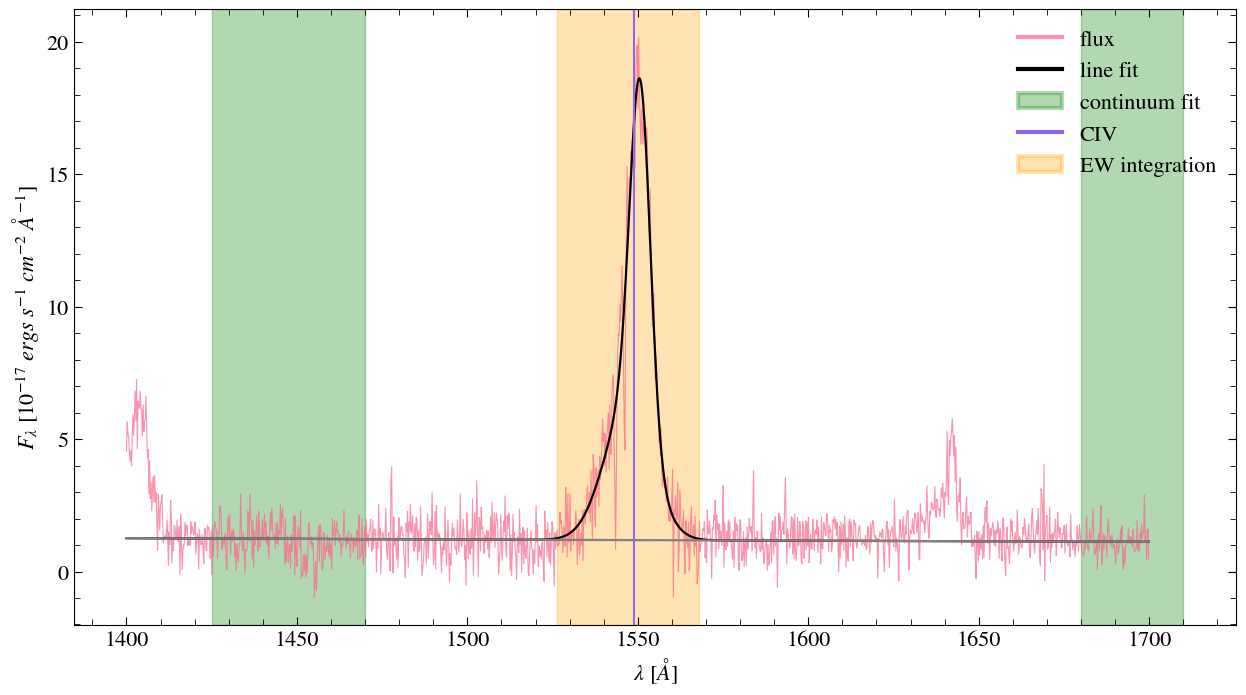


                SDSS: 233636.99+065231.0
                FWHM: 1646.998 vs 1483.559 (Hamann)
                REW: 156.934 vs 128.271 (Hamann) vs 156.178 (fit area)
                kt80: 0.292 vs 0.258 (Hamann)
    
---------------------------------------
---------------------------------------


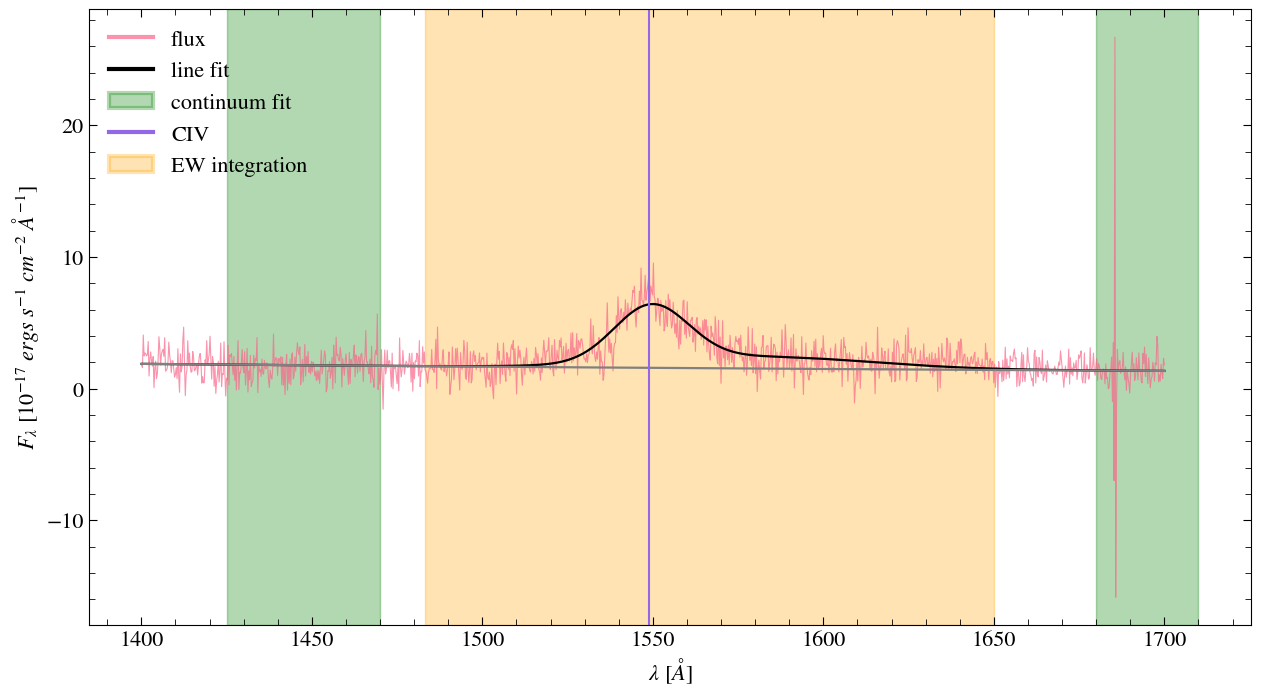


                SDSS: 082649.30+163945.2
                FWHM: 5479.07 vs 5633.199 (Hamann)
                REW: 131.496 vs 204.888 (Hamann) vs 122.425 (fit area)
                kt80: 0.299 vs 0.33 (Hamann)
    
---------------------------------------
---------------------------------------


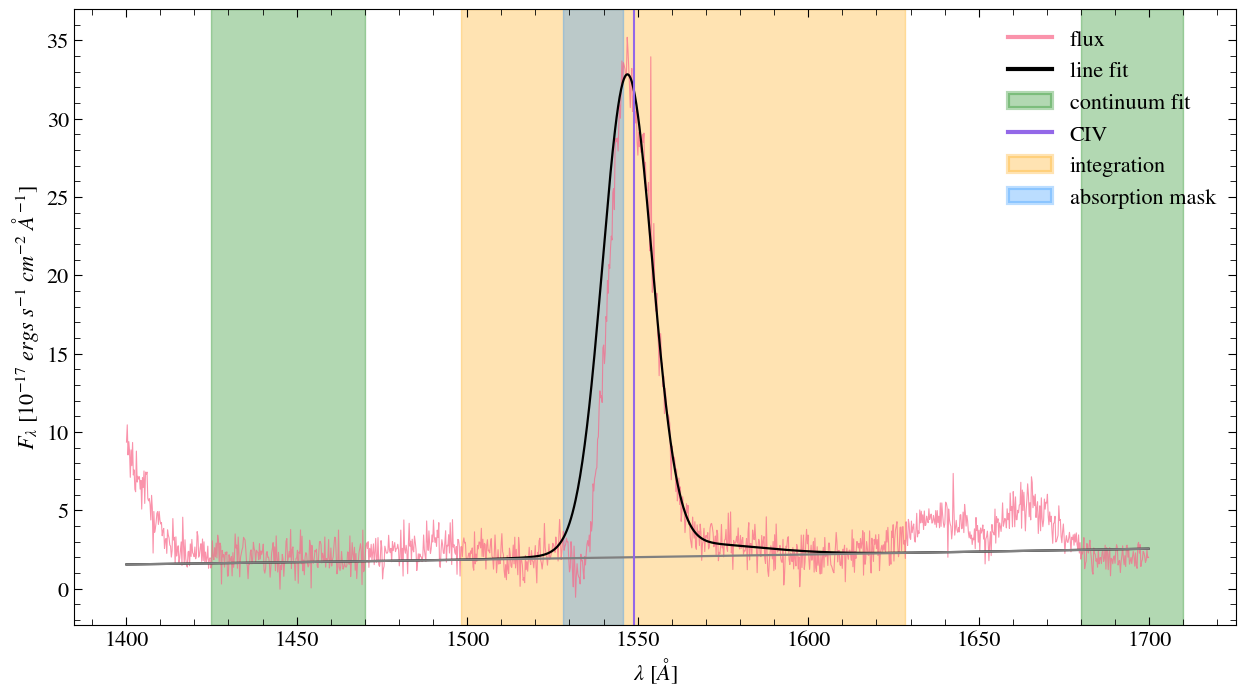


                SDSS: 083448.48+015921.1
                FWHM: 3351.699 vs 2863.092 (Hamann)
                REW: 256.638 vs 209.44 (Hamann) vs 297.101 (fit area)
                kt80: 0.368 vs 0.365 (Hamann)
    
---------------------------------------
---------------------------------------


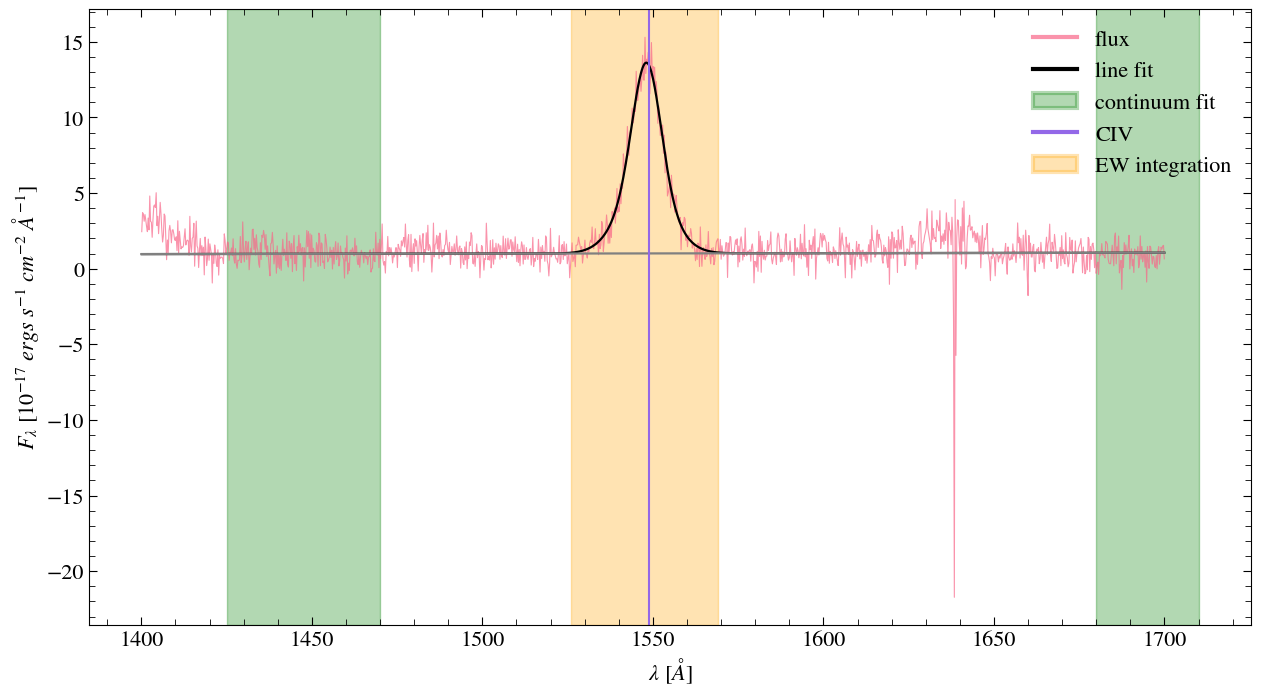


                SDSS: 131722.85+322207.5
                FWHM: 2204.388 vs 2310.771 (Hamann)
                REW: 161.305 vs 159.85 (Hamann) vs 161.259 (fit area)
                kt80: 0.338 vs 0.36 (Hamann)
    
---------------------------------------
---------------------------------------


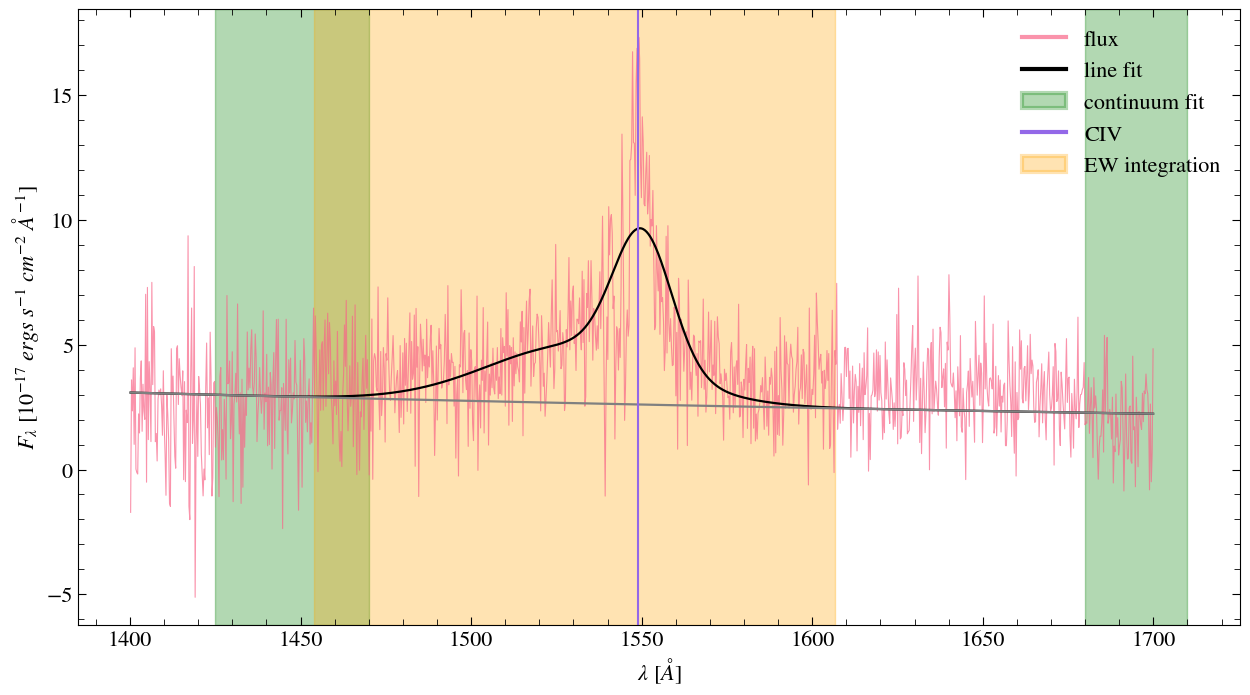


                SDSS: 082536.31+200040.3
                FWHM: 4859.371 vs 3265.175 (Hamann)
                REW: 115.952 vs 210.805 (Hamann) vs 99.051 (fit area)
                kt80: 0.212 vs 0.171 (Hamann)
    
---------------------------------------
---------------------------------------


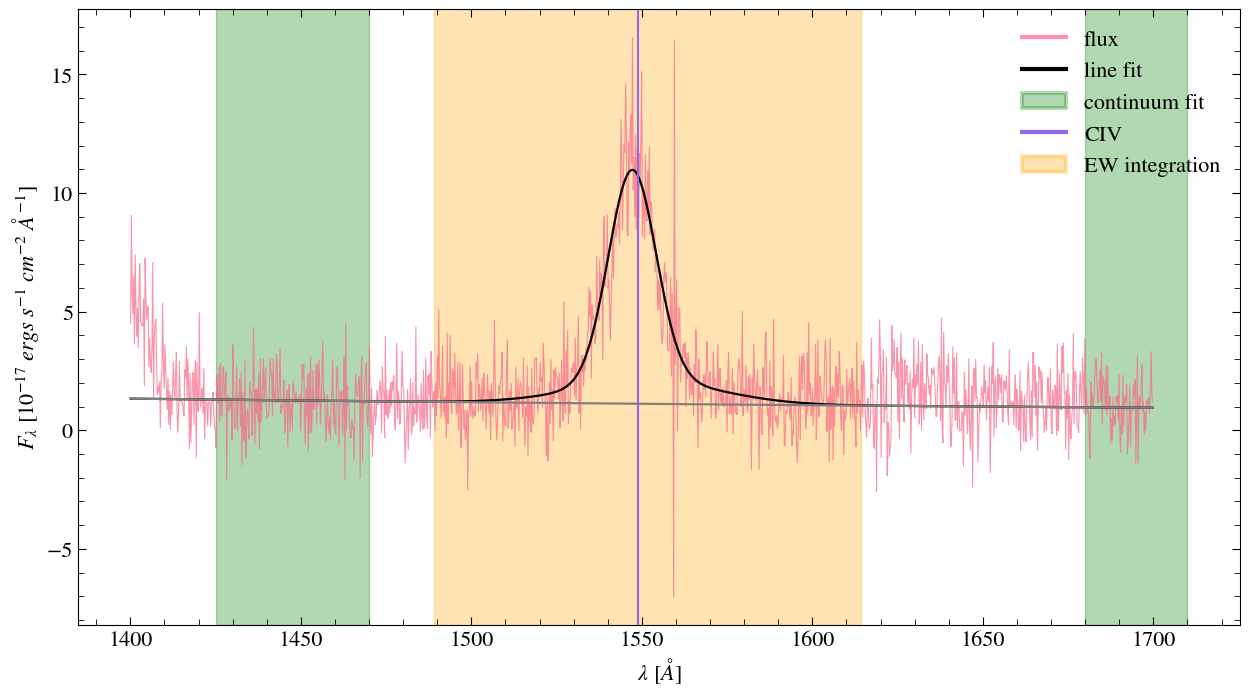


                SDSS: 130936.14+560111.3
                FWHM: 3387.29 vs 3629.606 (Hamann)
                REW: 189.072 vs 160.873 (Hamann) vs 184.602 (fit area)
                kt80: 0.351 vs 0.361 (Hamann)
    
---------------------------------------
---------------------------------------


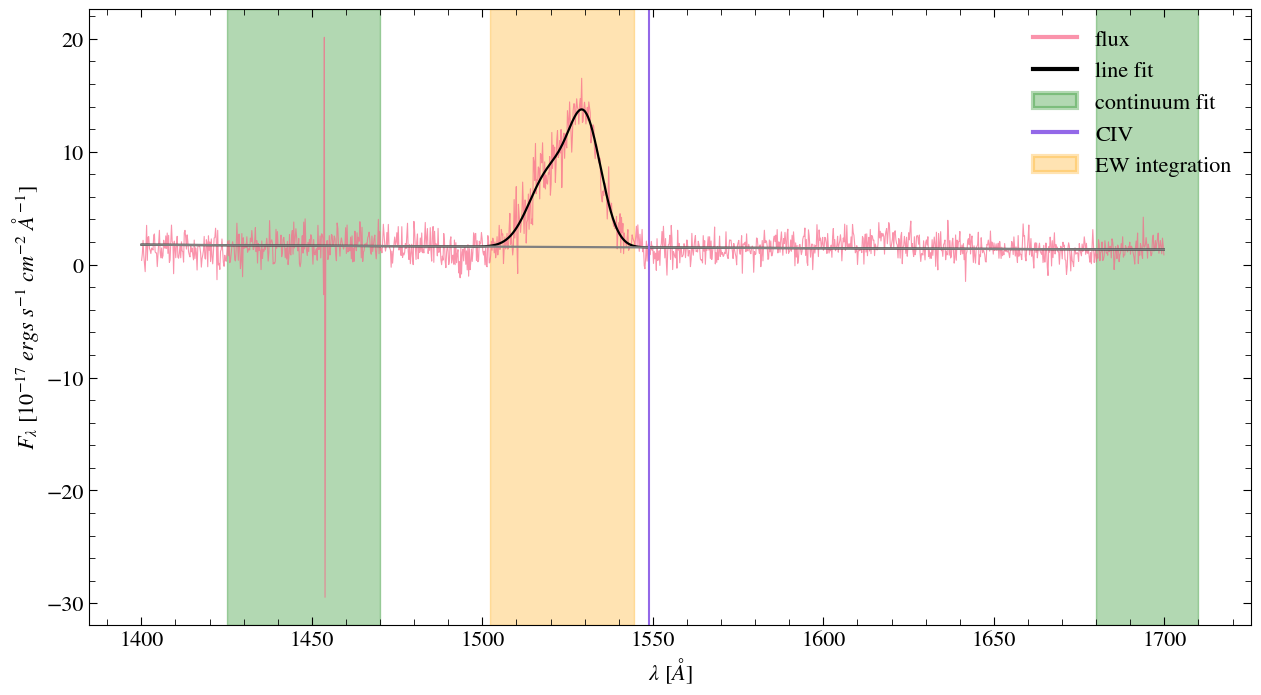


                SDSS: 002400.25+245031.9
                FWHM: 3512.651 vs 3523.282 (Hamann)
                REW: 142.01 vs 143.69 (Hamann) vs 142.185 (fit area)
                kt80: 0.307 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


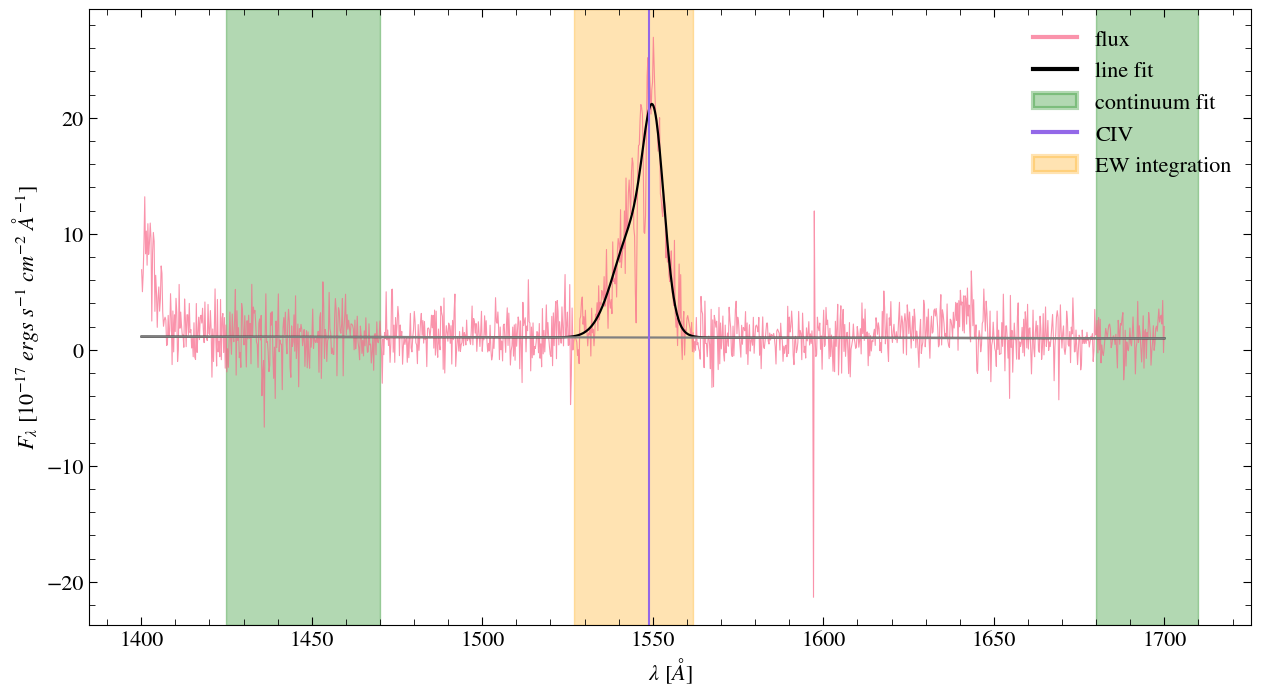


                SDSS: 134026.99+083427.2
                FWHM: 2003.048 vs 2075.846 (Hamann)
                REW: 232.21 vs 357.973 (Hamann) vs 229.125 (fit area)
                kt80: 0.266 vs 0.345 (Hamann)
    
---------------------------------------
---------------------------------------


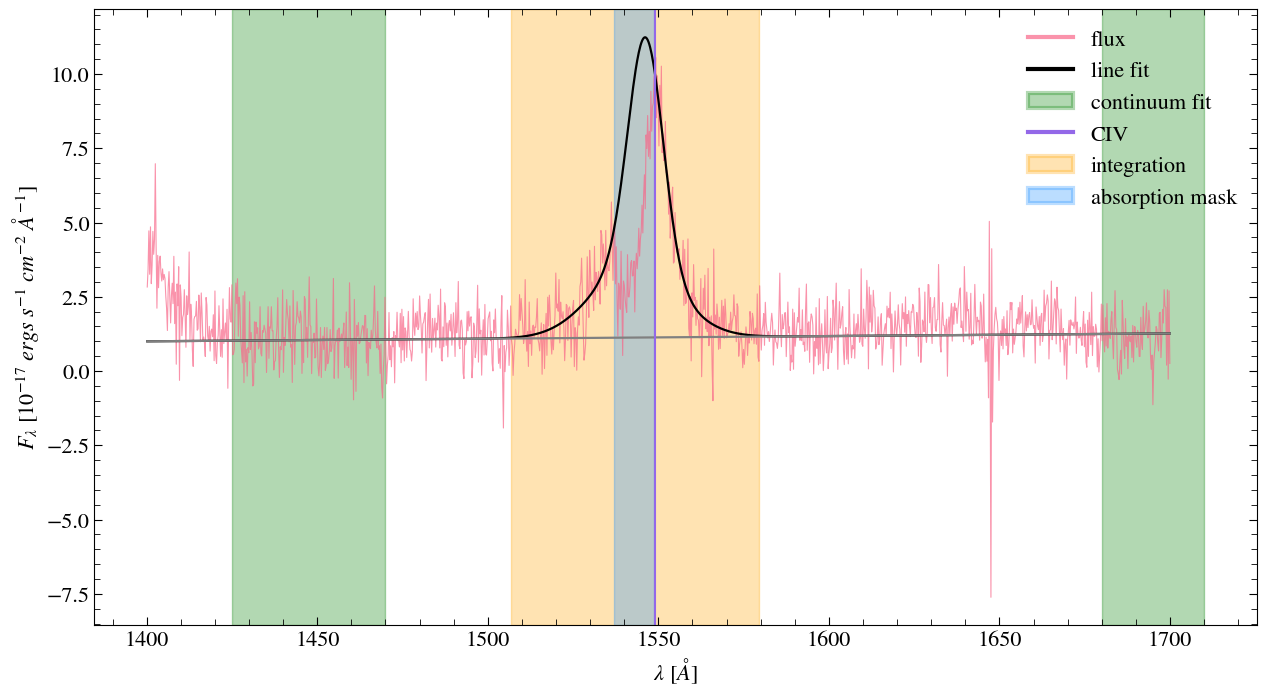


                SDSS: 134001.90+322155.9
                FWHM: 2713.634 vs 1822.703 (Hamann)
                REW: 108.047 vs 130.709 (Hamann) vs 153.972 (fit area)
                kt80: 0.318 vs 0.207 (Hamann)
    
---------------------------------------
---------------------------------------


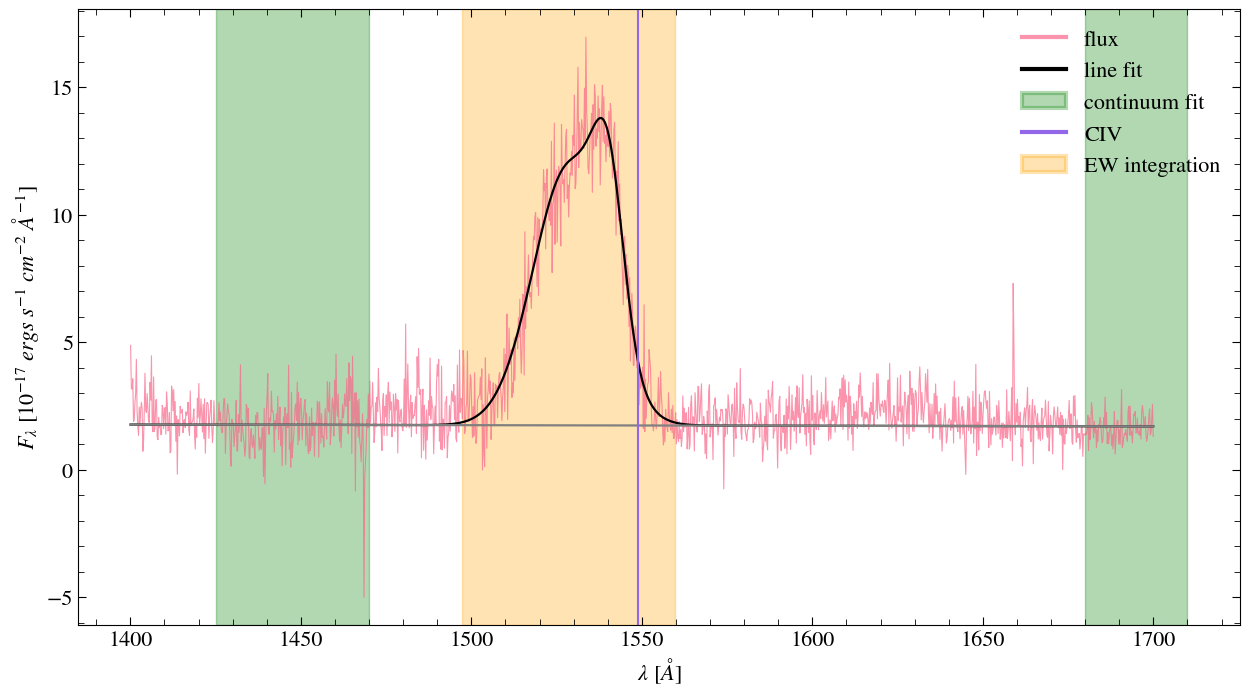


                SDSS: 104611.50+024351.6
                FWHM: 5296.498 vs 4854.269 (Hamann)
                REW: 192.12 vs 217.582 (Hamann) vs 190.736 (fit area)
                kt80: 0.448 vs 0.354 (Hamann)
    
---------------------------------------
---------------------------------------


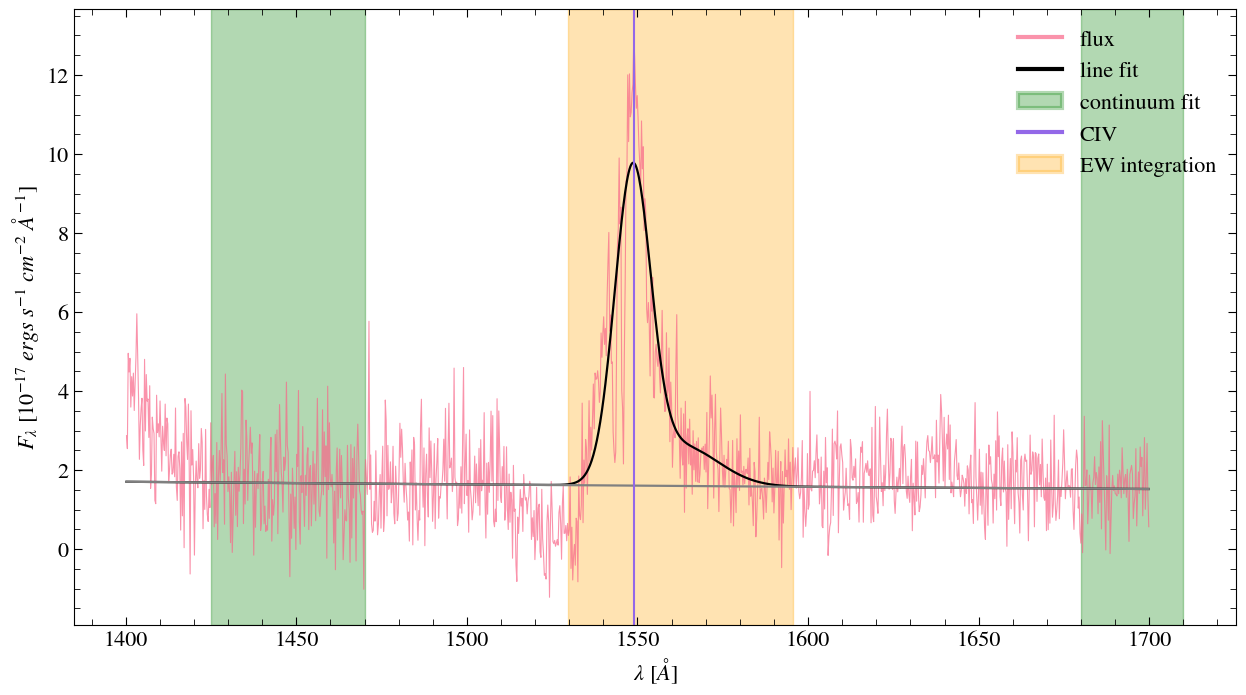


                SDSS: 093506.96-024137.7
                FWHM: 2518.526 vs 2404.04 (Hamann)
                REW: 80.586 vs 119.496 (Hamann) vs 80.494 (fit area)
                kt80: 0.345 vs 0.249 (Hamann)
    
---------------------------------------
---------------------------------------


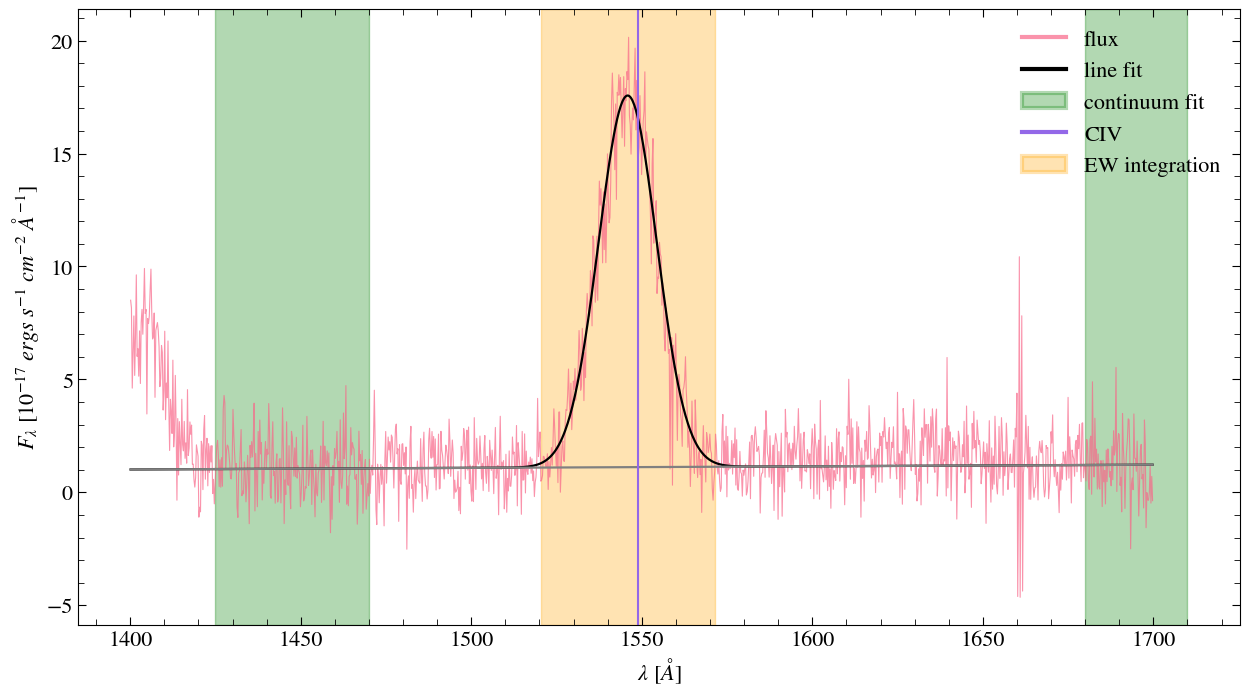


                SDSS: 232326.17-010033.1
                FWHM: 3883.785 vs 3989.27 (Hamann)
                REW: 313.63 vs 255.993 (Hamann) vs 313.96 (fit area)
                kt80: 0.372 vs 0.371 (Hamann)
    
---------------------------------------
---------------------------------------


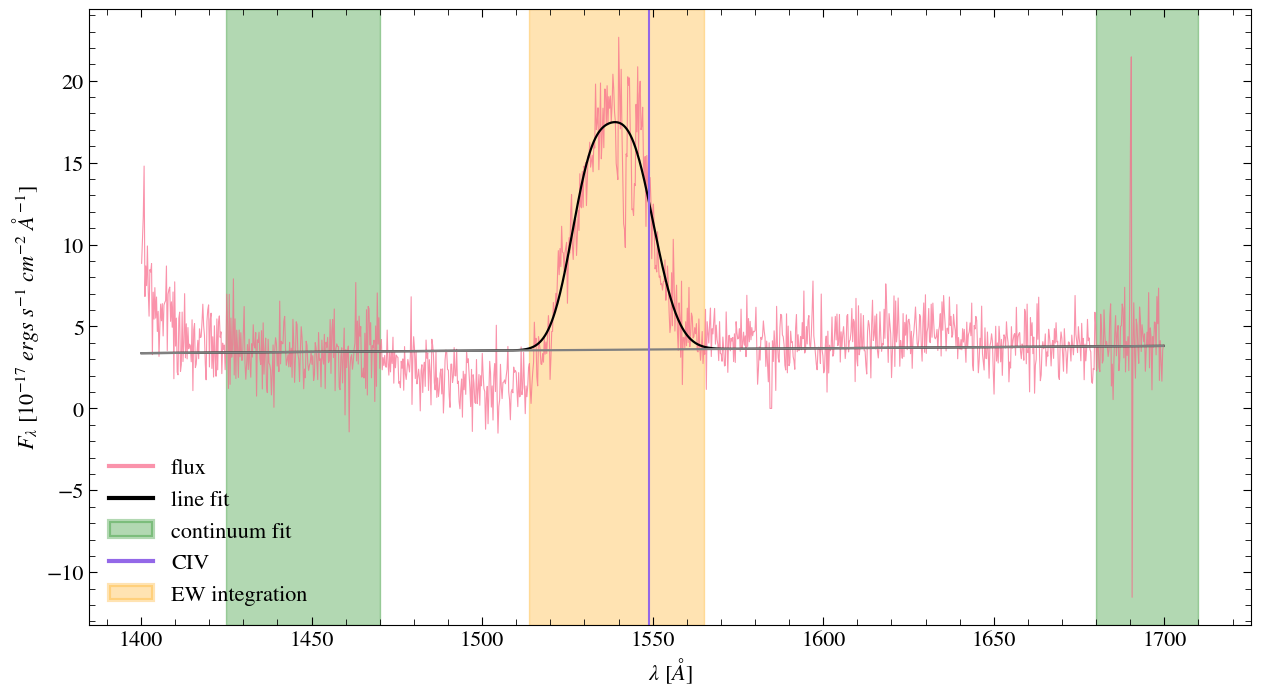


                SDSS: 103146.53+290324.1
                FWHM: 4777.692 vs 4363.774 (Hamann)
                REW: 97.087 vs 120.767 (Hamann) vs 97.711 (fit area)
                kt80: 0.483 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


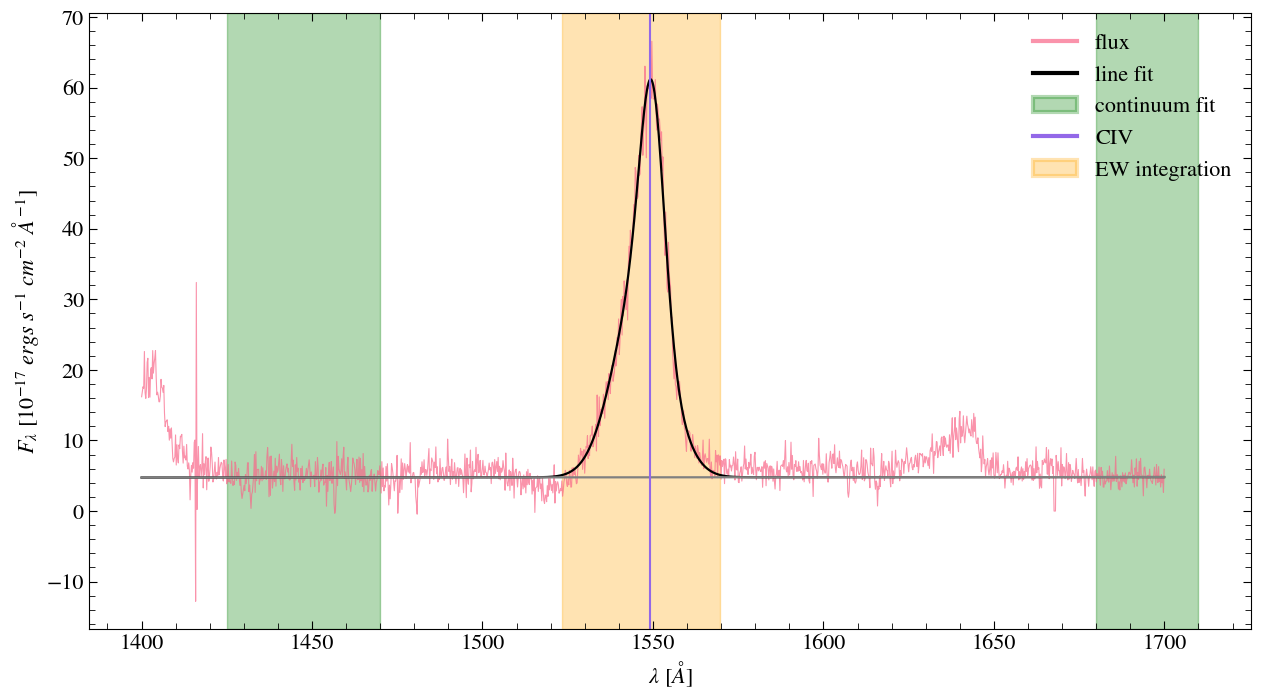


                SDSS: 165202.64+172852.3
                FWHM: 2304.666 vs 2403.322 (Hamann)
                REW: 169.288 vs 124.521 (Hamann) vs 168.584 (fit area)
                kt80: 0.28 vs 0.329 (Hamann)
    
---------------------------------------
---------------------------------------


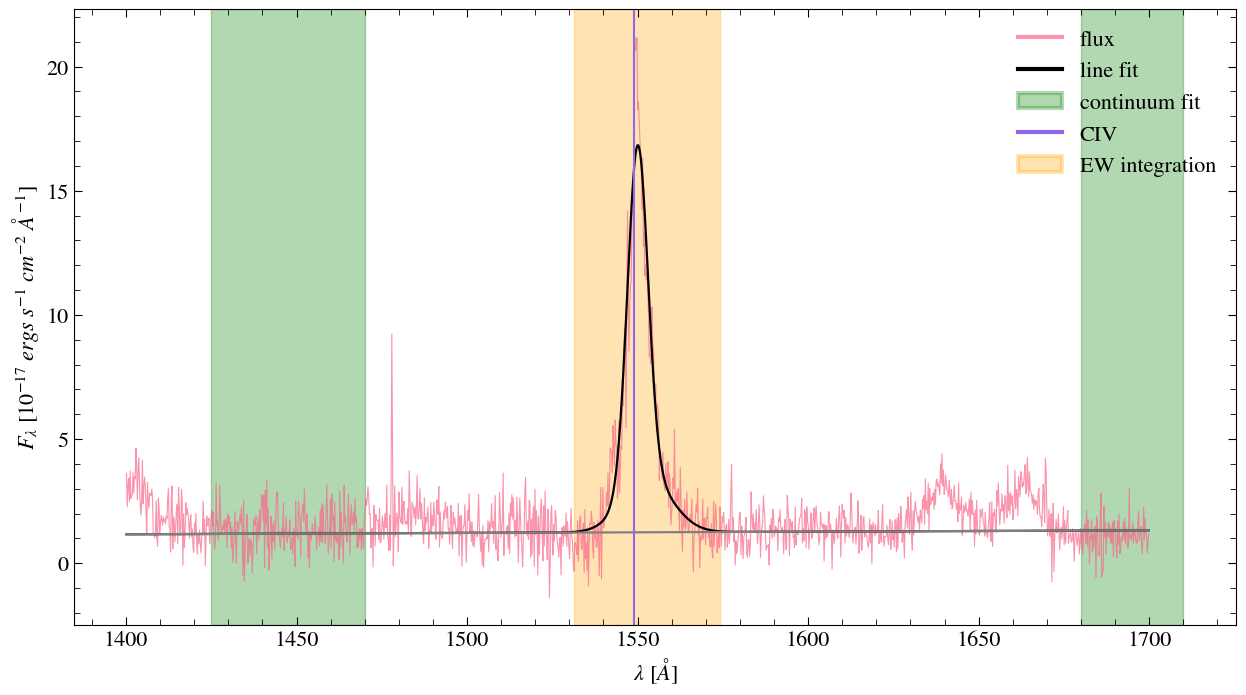


                SDSS: 122000.68+064045.3
                FWHM: 1483.272 vs 1047.131 (Hamann)
                REW: 112.055 vs 112.877 (Hamann) vs 112.895 (fit area)
                kt80: 0.345 vs 0.151 (Hamann)
    
---------------------------------------
---------------------------------------


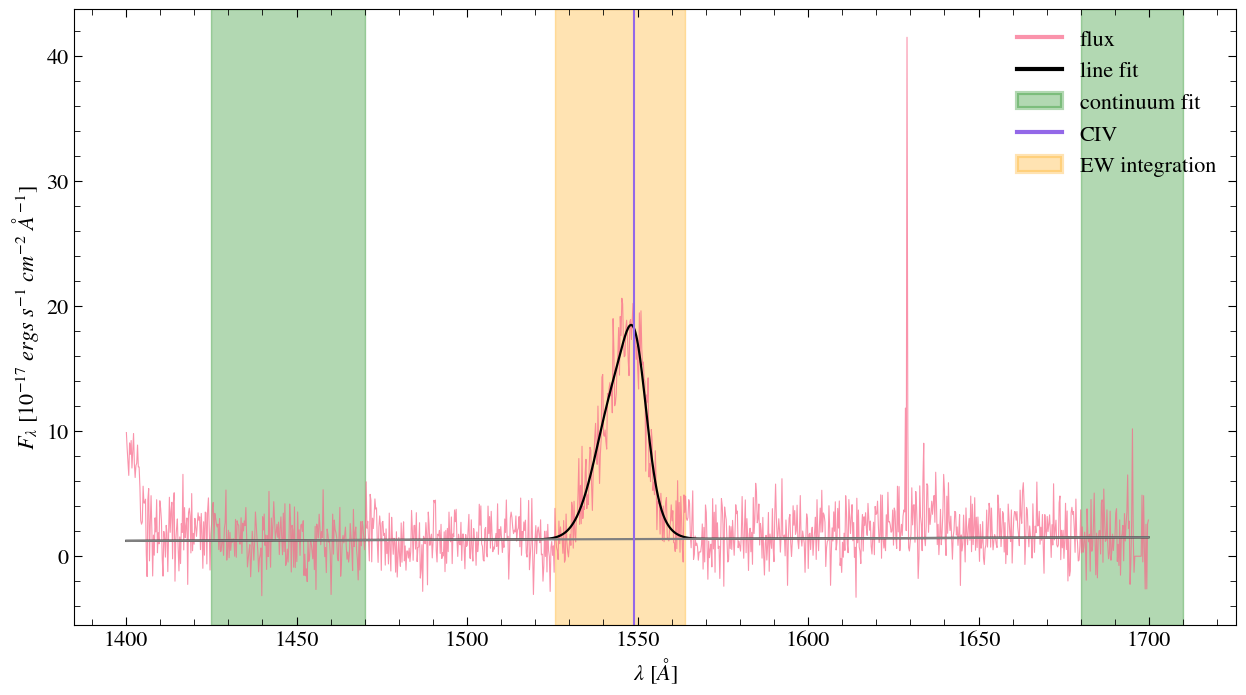


                SDSS: 121704.70+023417.1
                FWHM: 2729.708 vs 2603.968 (Hamann)
                REW: 186.728 vs 180.897 (Hamann) vs 186.113 (fit area)
                kt80: 0.338 vs 0.369 (Hamann)
    
---------------------------------------
---------------------------------------


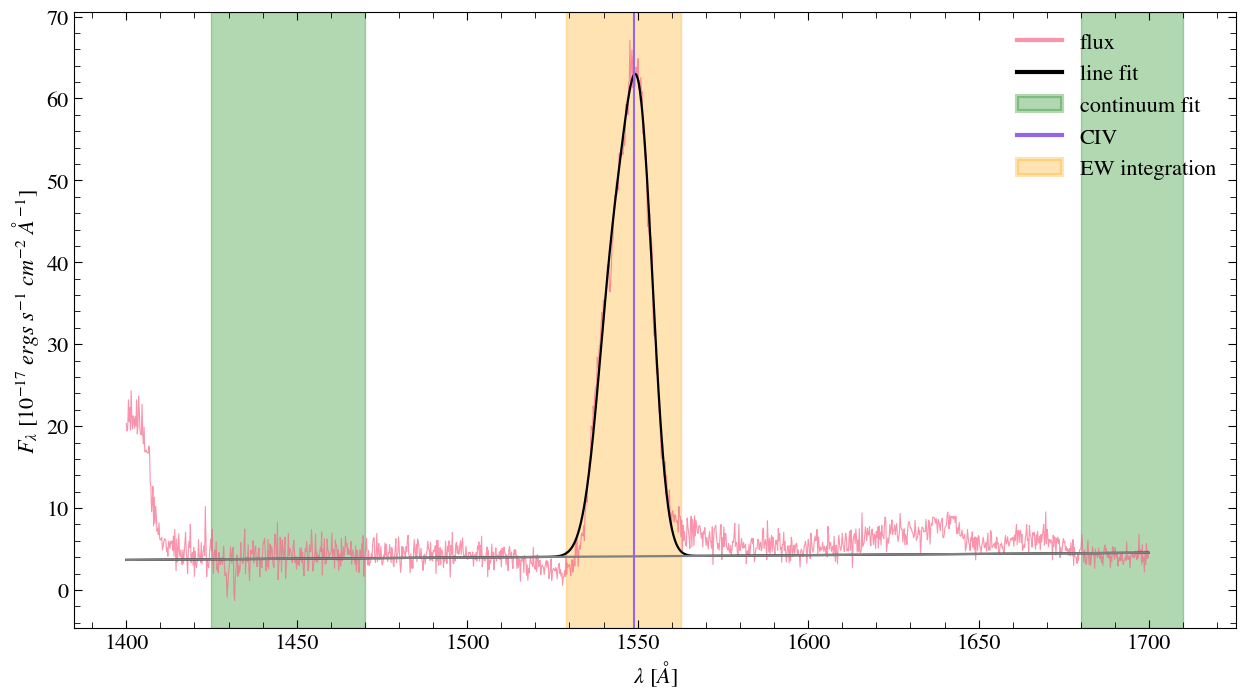


                SDSS: 131047.78+322518.3
                FWHM: 2864.005 vs 2793.839 (Hamann)
                REW: 215.724 vs 226.394 (Hamann) vs 215.703 (fit area)
                kt80: 0.381 vs 0.367 (Hamann)
    
---------------------------------------
---------------------------------------


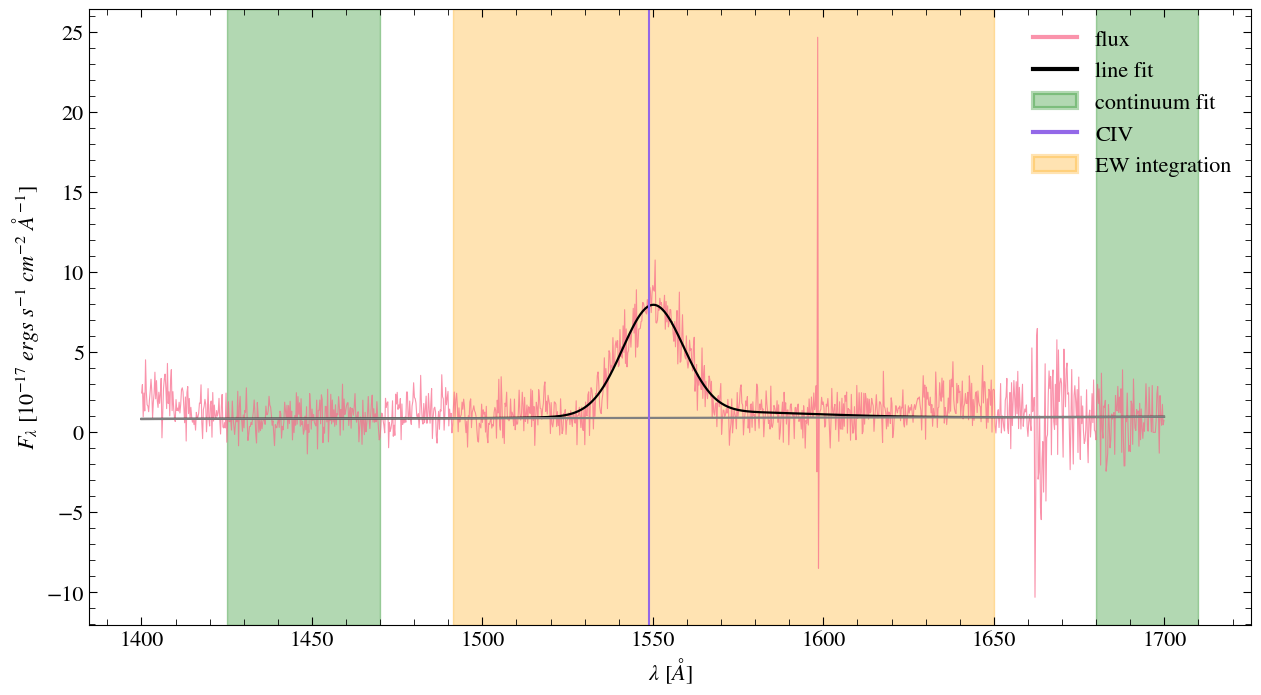


                SDSS: 221524.00-005643.8
                FWHM: 4180.691 vs 4280.102 (Hamann)
                REW: 230.521 vs 153.336 (Hamann) vs 194.749 (fit area)
                kt80: 0.363 vs 0.366 (Hamann)
    
---------------------------------------
---------------------------------------


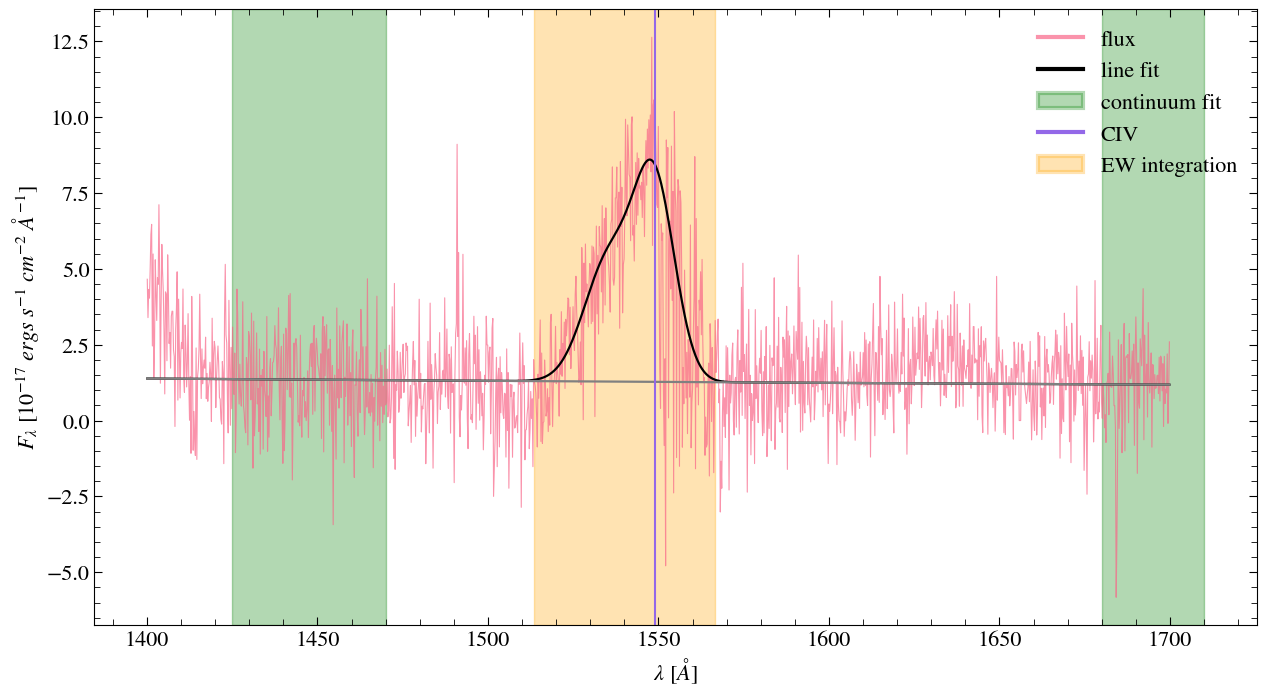


                SDSS: 134450.51+140139.2
                FWHM: 4517.98 vs 4487.034 (Hamann)
                REW: 124.574 vs 132.41 (Hamann) vs 132.457 (fit area)
                kt80: 0.315 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


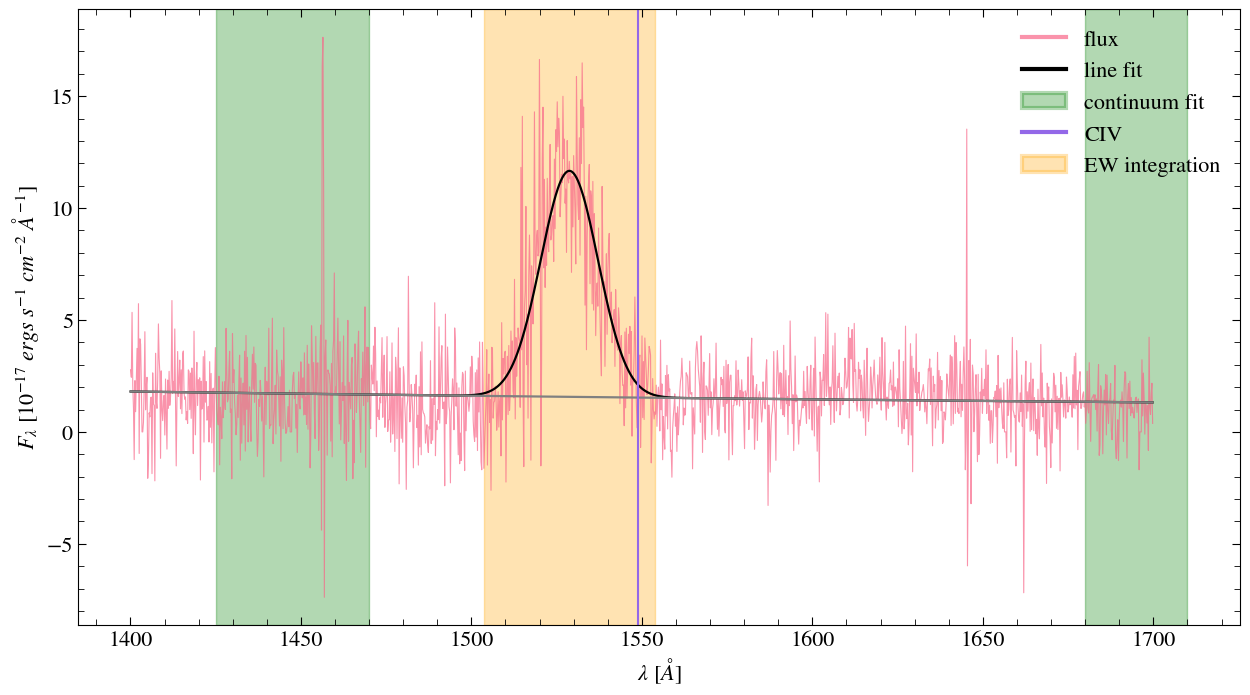


                SDSS: 153107.14+105825.8
                FWHM: 3822.298 vs 3936.554 (Hamann)
                REW: 139.671 vs 151.904 (Hamann) vs 135.267 (fit area)
                kt80: 0.372 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


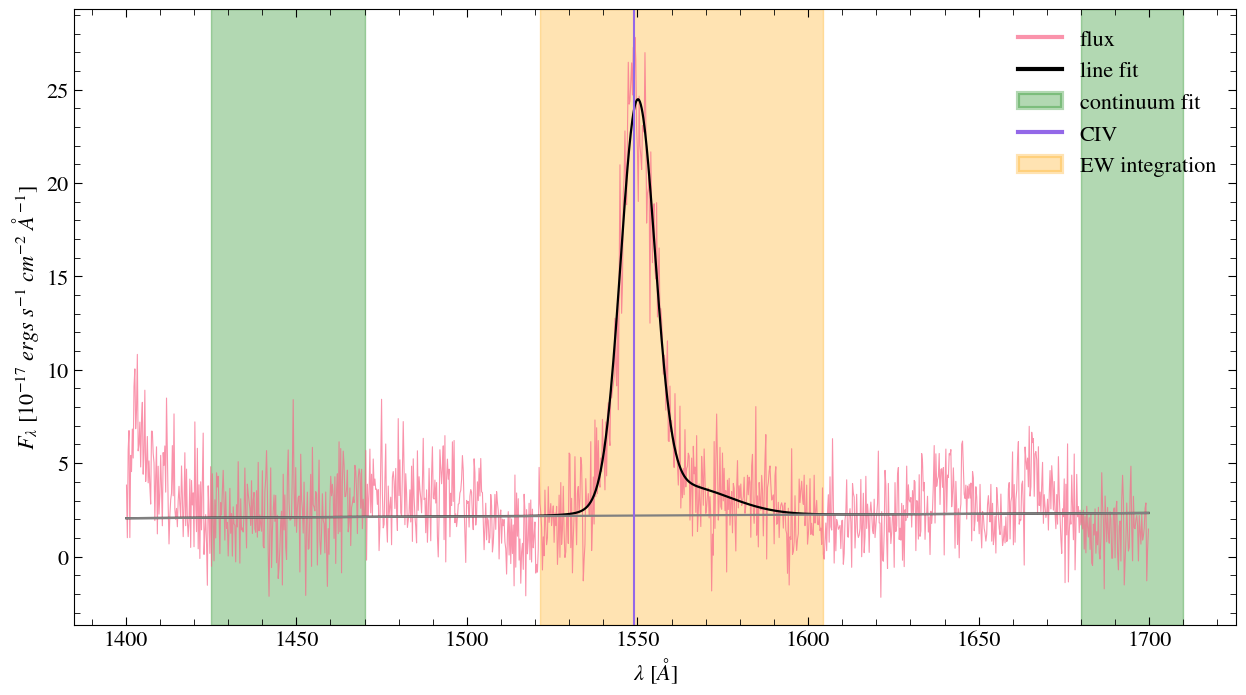


                SDSS: 104718.35+484433.8
                FWHM: 2363.88 vs 2521.46 (Hamann)
                REW: 145.702 vs 158.03 (Hamann) vs 146.52 (fit area)
                kt80: 0.359 vs 0.361 (Hamann)
    
---------------------------------------
---------------------------------------


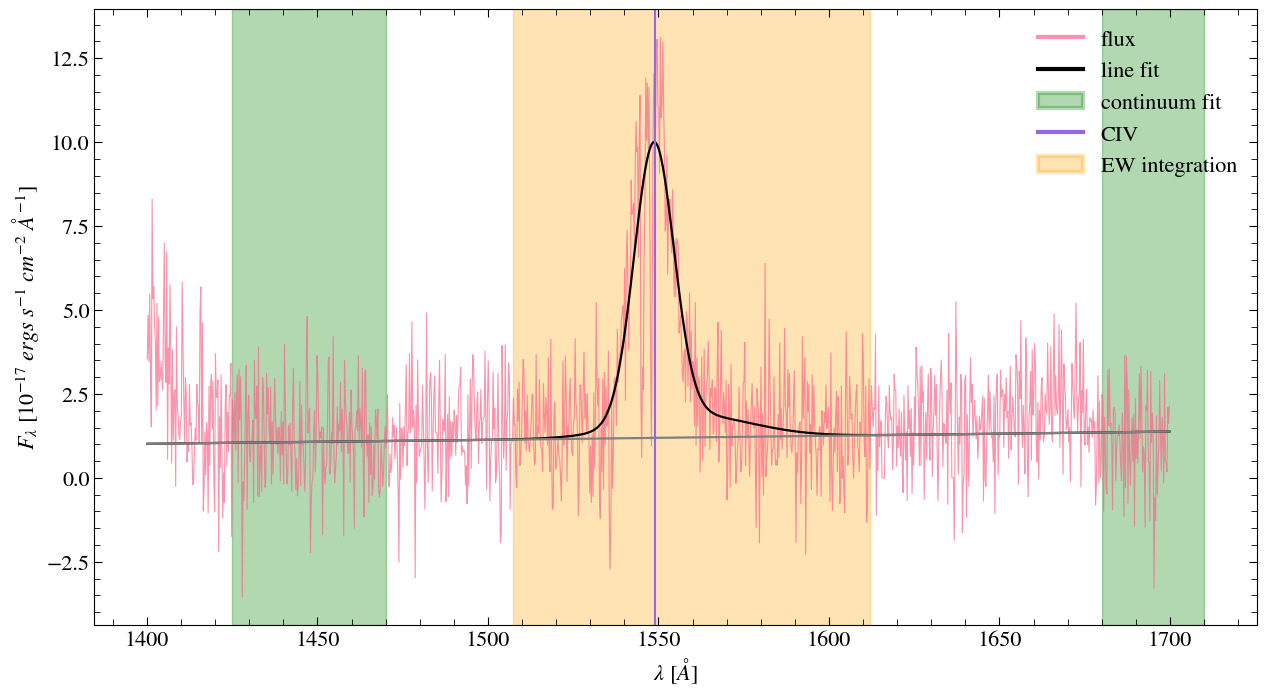


                SDSS: 020932.15+312202.7
                FWHM: 2766.247 vs 2180.064 (Hamann)
                REW: 128.856 vs 107.677 (Hamann) vs 125.184 (fit area)
                kt80: 0.357 vs 0.345 (Hamann)
    
---------------------------------------
---------------------------------------


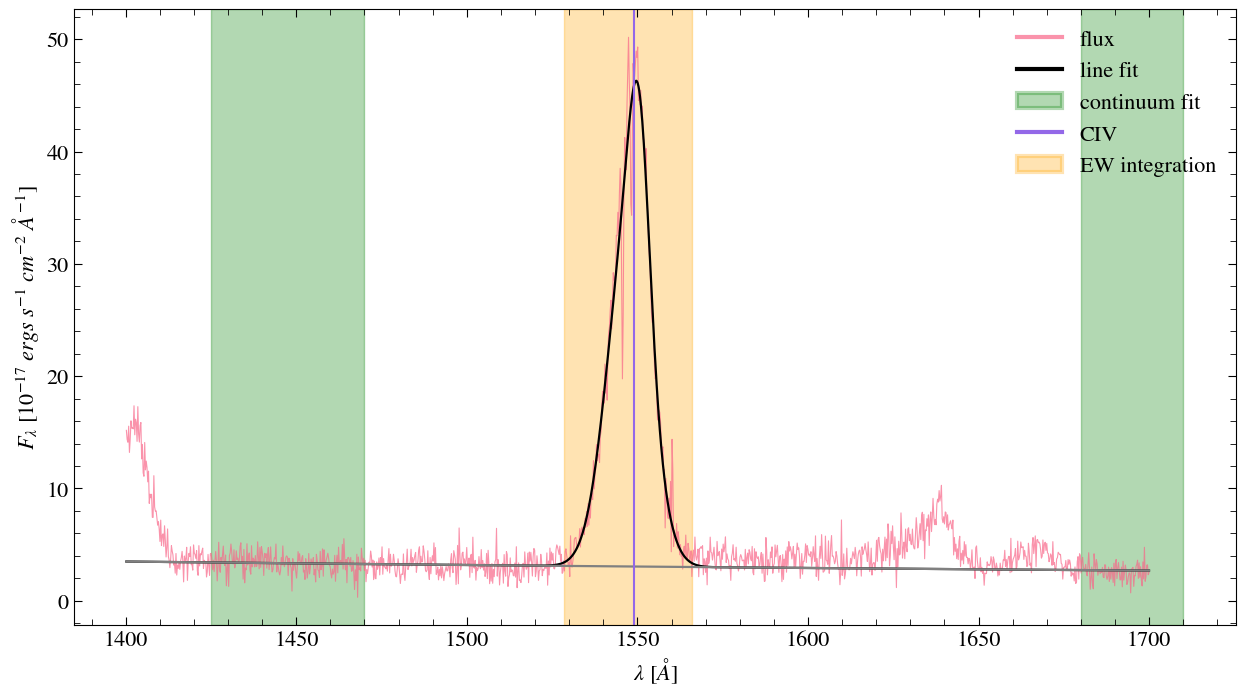


                SDSS: 082653.42+054247.3
                FWHM: 2382.644 vs 2433.822 (Hamann)
                REW: 192.865 vs 204.619 (Hamann) vs 191.164 (fit area)
                kt80: 0.313 vs 0.358 (Hamann)
    
---------------------------------------
---------------------------------------
ValueError in get_absorption_interval()


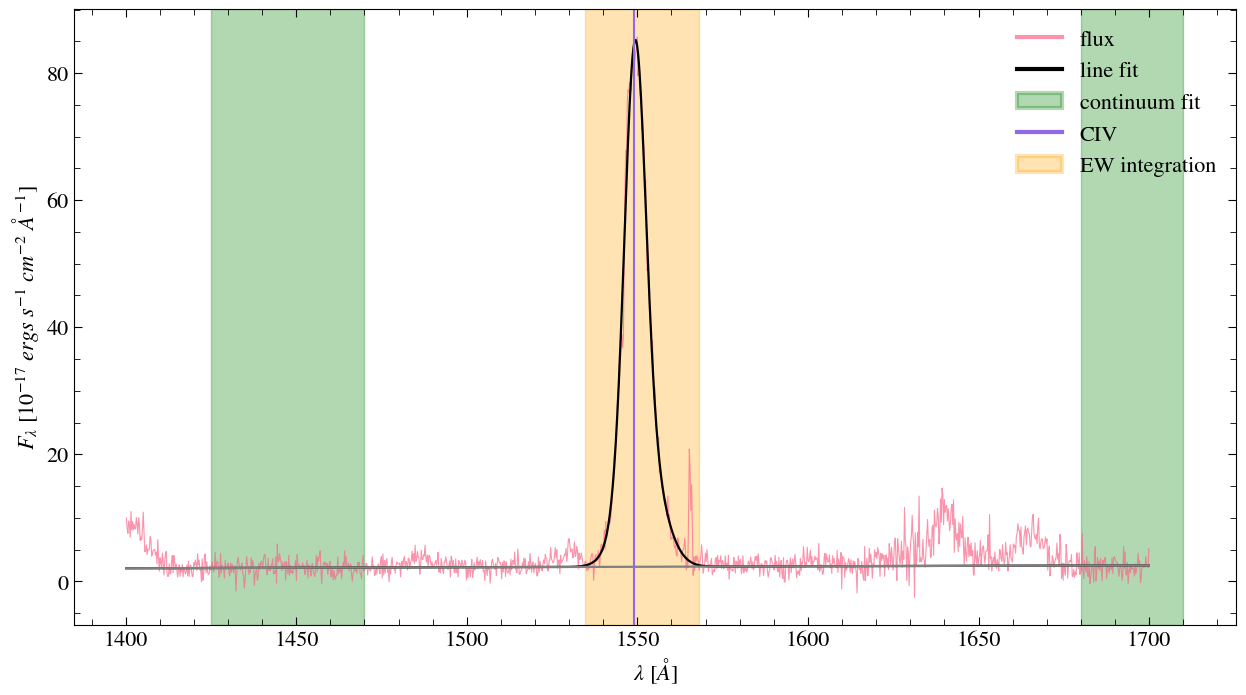


                SDSS: 232828.47+044346.8
                FWHM: 1566.295 vs 1583.693 (Hamann)
                REW: 334.907 vs 358.596 (Hamann) vs 331.26 (fit area)
                kt80: 0.342 vs 0.352 (Hamann)
    
---------------------------------------
---------------------------------------


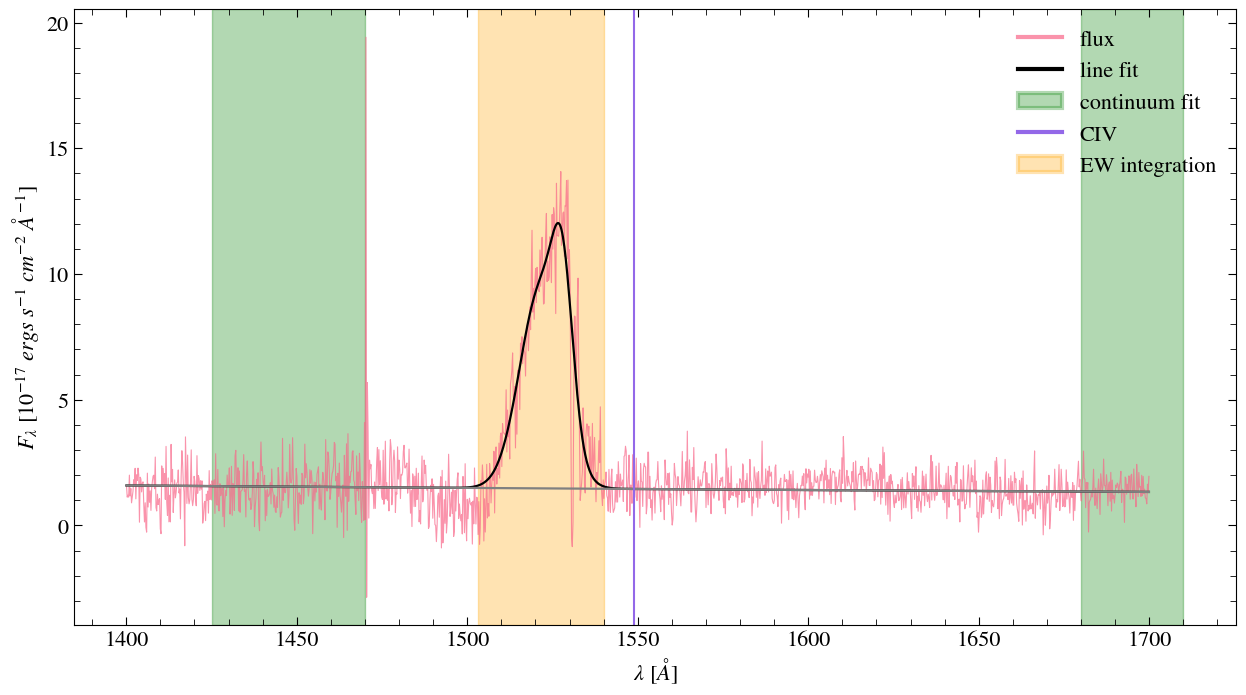


                SDSS: 154831.92+311951.4
                FWHM: 2959.109 vs 3050.048 (Hamann)
                REW: 110.155 vs 127.184 (Hamann) vs 110.949 (fit area)
                kt80: 0.353 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


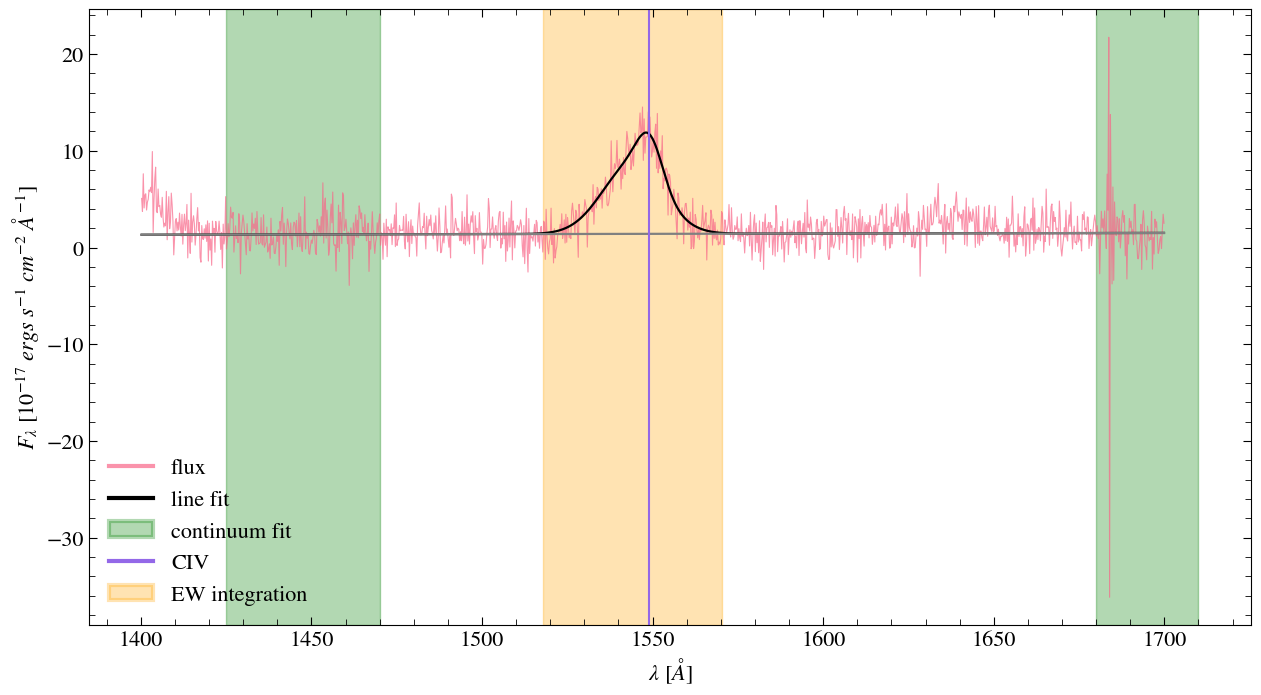


                SDSS: 080547.66+454159.0
                FWHM: 3348.793 vs 2667.071 (Hamann)
                REW: 138.677 vs 108.69 (Hamann) vs 139.253 (fit area)
                kt80: 0.293 vs 0.211 (Hamann)
    
---------------------------------------
---------------------------------------


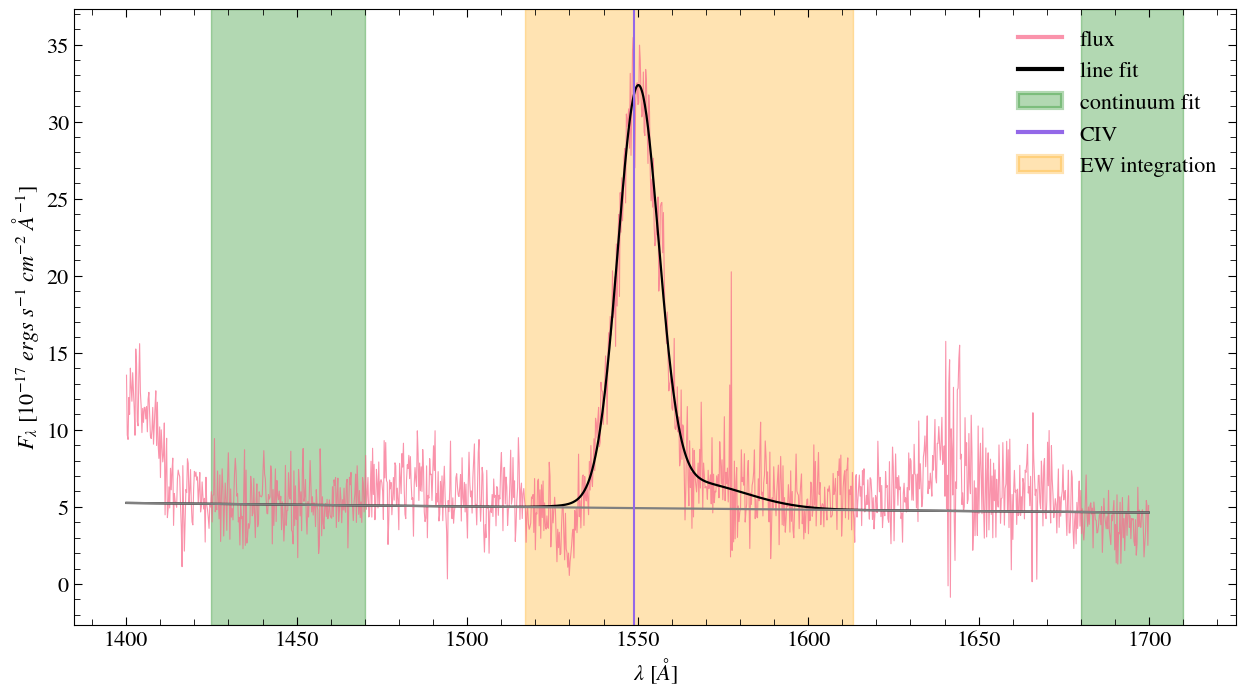


                SDSS: 014111.13-031852.5
                FWHM: 2807.719 vs 2985.648 (Hamann)
                REW: 93.748 vs 101.008 (Hamann) vs 94.471 (fit area)
                kt80: 0.361 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


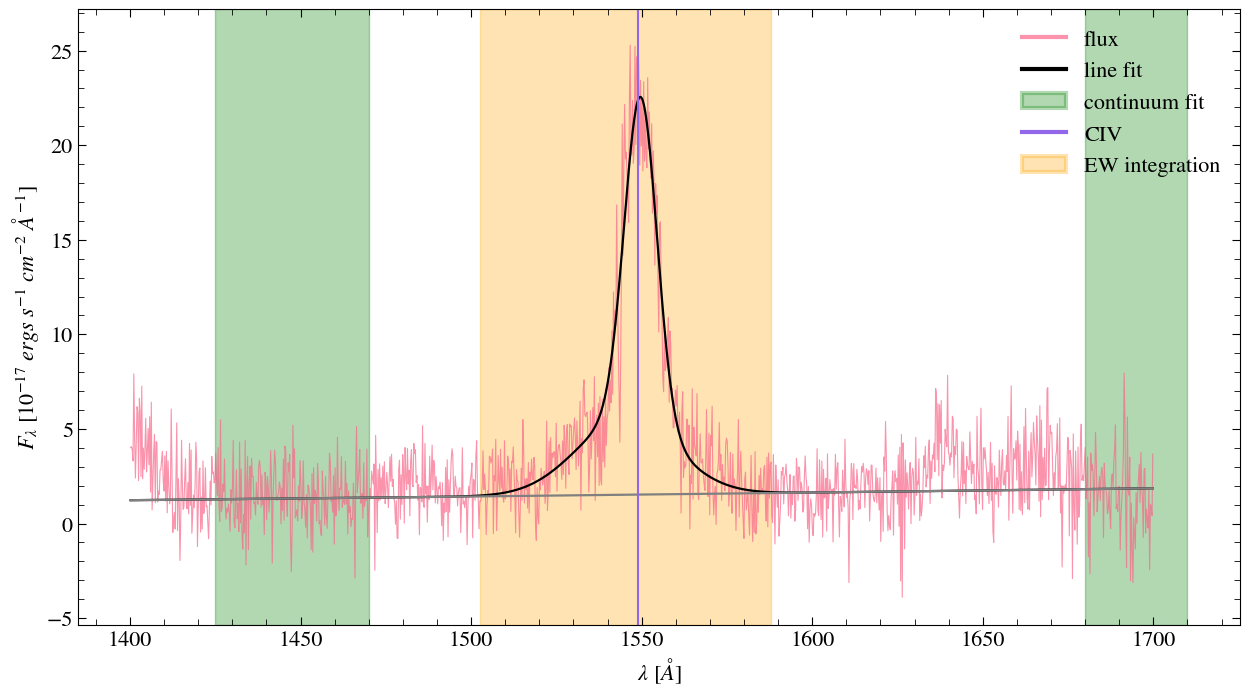


                SDSS: 000746.19+122223.9
                FWHM: 2470.027 vs 2432.83 (Hamann)
                REW: 236.793 vs 219.634 (Hamann) vs 228.093 (fit area)
                kt80: 0.319 vs 0.284 (Hamann)
    
---------------------------------------
---------------------------------------


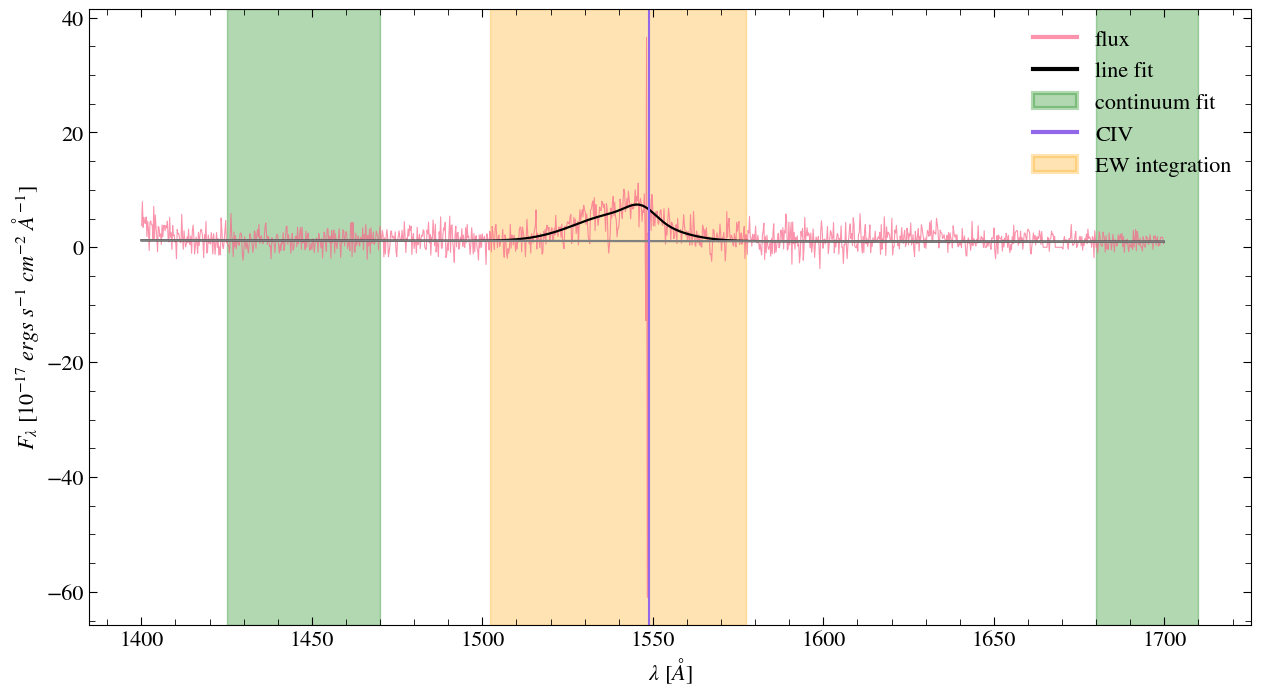


                SDSS: 085451.11+173009.1
                FWHM: 4763.342 vs 4199.357 (Hamann)
                REW: 156.115 vs 120.014 (Hamann) vs 156.64 (fit area)
                kt80: 0.266 vs 0.37 (Hamann)
    
---------------------------------------
---------------------------------------


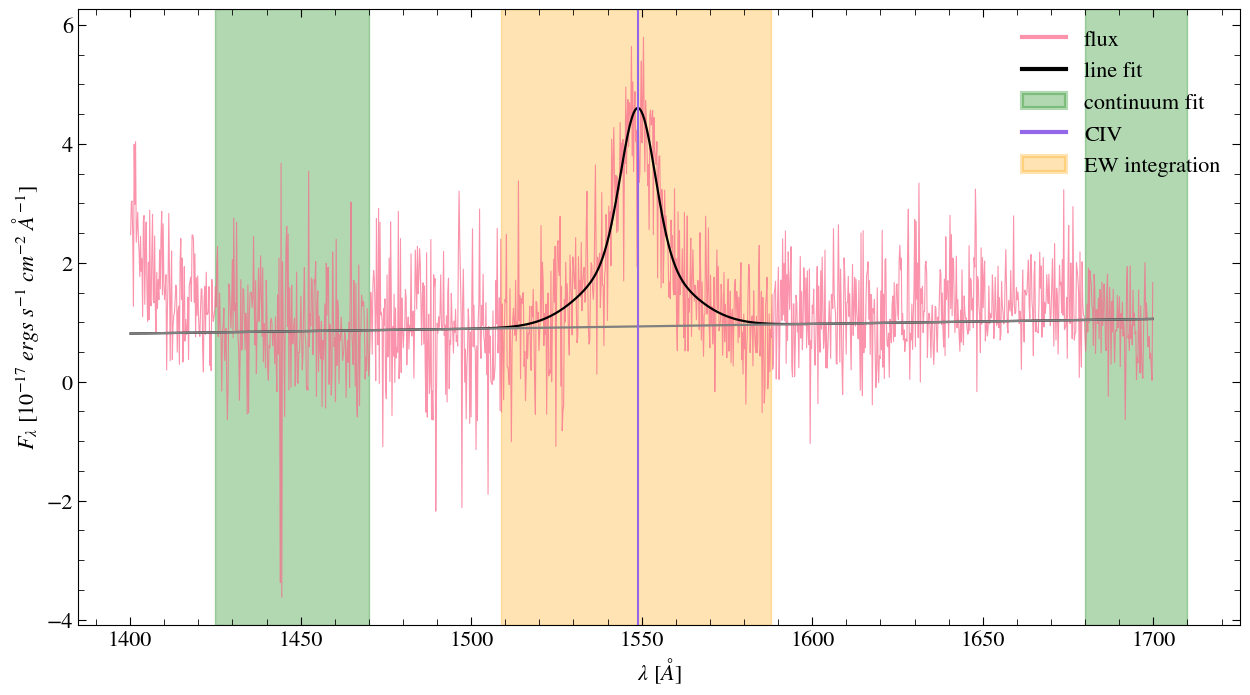


                SDSS: 102447.32-013633.8
                FWHM: 2817.175 vs 2843.202 (Hamann)
                REW: 72.386 vs 192.349 (Hamann) vs 74.69 (fit area)
                kt80: 0.286 vs 0.148 (Hamann)
    


In [10]:
for i in range(len(data)):
    if data["sdss_name"][i] in valid_sdss_names:
        print("---------------------------------------\n---------------------------------------")
        sanity_tests(i)

In [11]:
stats = data[data["my_rew"].notnull()][['sdss_name','redshift', 'rew', 'fwhm', 'kt80', 'my_fwhm', 'my_rew', 'my_kt80']]

stats["rew_abs_diff"] = stats["my_rew"] - stats["rew"]
stats["fwhm_abs_diff"] = stats["my_fwhm"] - stats["fwhm"]
stats["kt80_abs_diff"] = stats["my_kt80"] - stats["kt80"]

stats["rew_rel_diff"] = stats["rew_abs_diff"] / stats["rew"]
stats["fwhm_rel_diff"] = stats["fwhm_abs_diff"] / stats["fwhm"] 
stats["kt80_rel_diff"] = stats["kt80_abs_diff"] / stats["kt80"]

stats

,sdss_name,redshift,rew,fwhm,kt80,my_fwhm,my_rew,my_kt80,rew_abs_diff,fwhm_abs_diff,kt80_abs_diff,rew_rel_diff,fwhm_rel_diff,kt80_rel_diff
0,233636.99+065231.0,2.775400,128.270560,1483.558675,0.258239,1646.998093,156.93364,0.292488,28.66308,163.439419,0.034249,0.223458,0.110167,0.132625
2,082649.30+163945.2,2.310120,204.888419,5633.198558,0.329619,5479.070281,131.495743,0.299012,-73.392676,-154.128277,-0.030607,-0.358208,-0.027361,-0.092855
3,083448.48+015921.1,2.590582,209.439757,2863.092351,0.364786,3351.698934,256.63811,0.367542,47.198353,488.606583,0.002757,0.225355,0.170657,0.007557
5,131722.85+322207.5,2.404809,159.849854,2310.771010,0.359501,2204.388282,161.304852,0.338059,1.454997,-106.382728,-0.021443,0.009102,-0.046038,-0.059646
6,082536.31+200040.3,2.088145,210.804566,3265.174575,0.171451,4859.371223,115.952133,0.212006,-94.852434,1594.196648,0.040555,-0.449954,0.488242,0.236541
7,130936.14+560111.3,2.576908,160.872544,3629.606223,0.360732,3387.289761,189.072073,0.350871,28.19953,-242.316462,-0.009861,0.175291,-0.066761,-0.027336
12,002400.25+245031.9,2.837482,143.689957,3523.281699,0.372201,3512.650941,142.009787,0.30724,-1.68017,-10.630757,-0.064961,-0.011693,-0.003017,-0.174532
13,134026.99+083427.2,2.492270,357.973489,2075.845539,0.345148,2003.048022,232.210113,0.266046,-125.763376,-72.797517,-0.079102,-0.35132,-0.035069,-0.229183
14,134001.90+322155.9,2.386438,130.708645,1822.703397,0.207409,2713.63392,108.047197,0.318358,-22.661448,890.930523,0.110949,-0.173374,0.488796,0.534928
16,104611.50+024351.6,2.799161,217.581636,4854.268520,0.354079,5296.497674,192.120325,0.448205,-25.461311,442.229154,0.094125,-0.11702,0.091101,0.265831


In [12]:
current_stats_path = "data/local/desi_current_best_measurements.csv"

stats.to_csv(current_stats_path)